# CLEAN Reconstruction Example

This notebook demonstrates 1D CLEAN reconstruction for Faraday depth.

CLEAN starts from the dirty spectrum, finds peaks iteratively, adds scaled components to the model, and subtracts the scaled RMTF from the residual. The result is then restored (model convolved with clean beam plus residual) in the same way as FISTA/CG.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from csromer.simulation import FaradayThinSource
from csromer.pipelines.simulation import run_simulation, SimulateStep, ApplyNoiseStep
from csromer.pipelines.reconstruction import CLEANReconstructorWrapper
from csromer.utils.array_utils import asnumpy

plt.rcParams['figure.figsize'] = (14, 8)
%matplotlib inline

## 1. Create Test Source

In [2]:
# Create source and run simulation pipeline
nu = np.linspace(1.0e9, 1.5e9, 128)
source = FaradayThinSource(
    nu=nu,
    s_nu=0.1,
    phi_gal=50.0,
    spectral_idx=-0.7,
)
run_simulation(source, [
    SimulateStep(),
    ApplyNoiseStep(0.01, random_state=np.random.RandomState(42)),
])

print(f"Source:")
print(f"  True RM: {source.phi_gal:.2f} rad/m²")
print(f"  Flux: {source.s_nu:.3f} Jy")

Source:
  True RM: 50.00 rad/m²
  Flux: 0.100 Jy


## 2. Run CLEAN Reconstruction

In [3]:
# Create CLEAN reconstructor (1D CLEAN from dirty map)
source.l2_ref = source.calculate_l2ref()
recon = CLEANReconstructorWrapper(
    dataset=source,
    oversampling=7.0,
    measurement_operator_kind="gridded",
    clean_gain=0.2,
    clean_maxiter=500,
    clean_threshold=None,
    clean_n_sigma=3.0,
)

# Run reconstruction
recon.reconstruct()

print(f"\nReconstruction Results:")
print(f"  Dirty RM: {recon.rm_dirty:.2f} rad/m²")
print(f"  Model RM: {recon.rm_model:.2f} rad/m²")
print(f"  Restored RM: {recon.rm_restored:.2f} rad/m²")
print(f"  True RM: {source.phi_gal:.2f} rad/m²")

FWHM of the main peak of the RMTF: 69.378 rad/m^2
Maximum recovered width structure: 78.649 rad/m^2
Maximum Faraday Depth to which one has more than 50% sensitivity: 4405.503
Convolving with Gaussian kernel where FWHM 67.469 rad/m^2 - sigma 28.651 rad/m^2 - sigma_pixels 2.8095
  [convolve_fd] kernel len=23 sum=7.042184 max=1.000000 (peak=1)
Convolving with Gaussian kernel where FWHM 67.469 rad/m^2 - sigma 28.651 rad/m^2 - sigma_pixels 2.8095
  [convolve_fd] kernel len=23 sum=7.042184 max=1.000000 (peak=1)
Convolving with Gaussian kernel where FWHM 67.469 rad/m^2 - sigma 28.651 rad/m^2 - sigma_pixels 2.8095
  [convolve_fd] kernel len=23 sum=7.042184 max=1.000000 (peak=1)
[restore DEBUG]
  cellsize=10.197924  rmtf_fwhm=67.468920  pixels_per_rmtf=6.6159
  peak:  dirty=9.960132e-02  model=8.734403e-02  residual=2.681245e-04
  peak:  conv_model(Jy/rmtf)=9.968459e-02 restored=9.989490e-02
  sum|model|=1.267457e-01  sum|conv_model|=8.093200e-01
  peak:  conv_abs_model=1.045852e-01 (amp-restor

## 3. Visualize Results

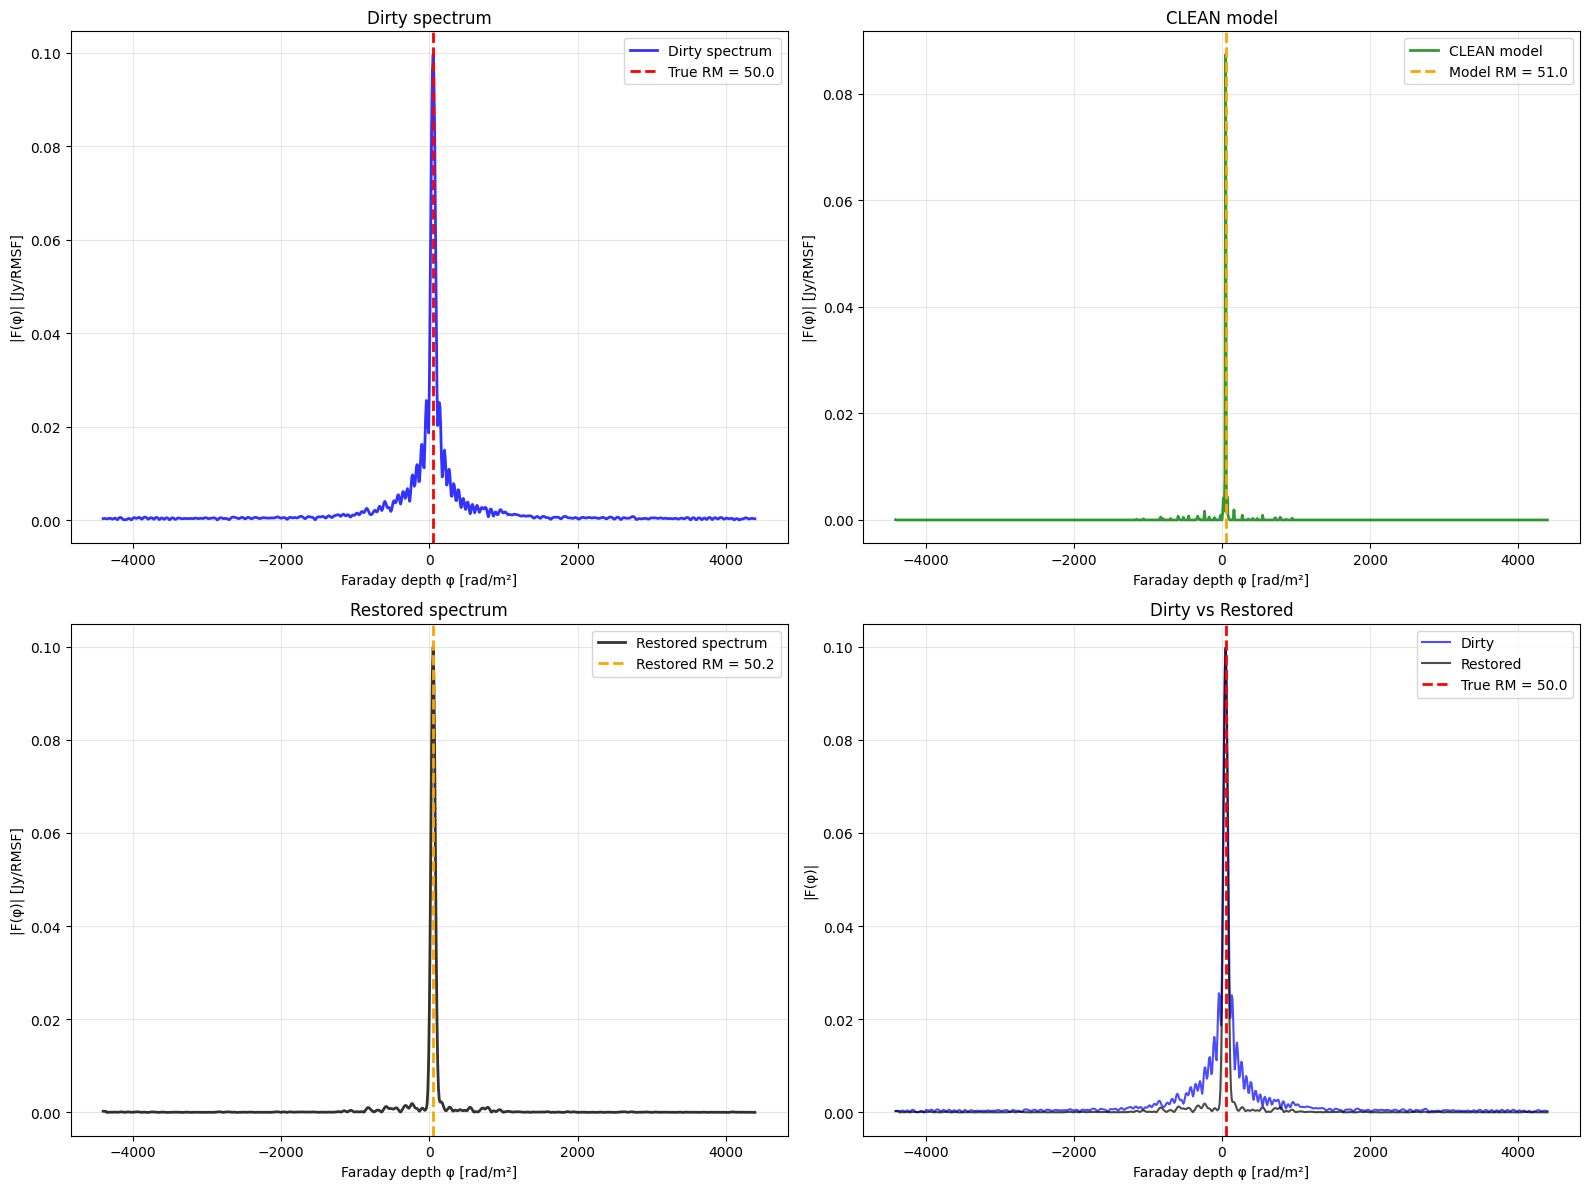

In [4]:
phi = np.asarray(asnumpy(recon.parameter.phi))
fd_dirty = np.asarray(asnumpy(recon.fd_dirty))
fd_model = np.asarray(asnumpy(recon.fd_model))
fd_restored_abs = np.abs(np.asarray(asnumpy(recon.fd_restored)))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Dirty spectrum
ax = axes[0, 0]
ax.plot(phi, np.abs(fd_dirty), 'b-', linewidth=2, label='Dirty spectrum', alpha=0.8)
ax.axvline(source.phi_gal, color='r', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.set_xlabel('Faraday depth φ [rad/m²]')
ax.set_ylabel('|F(φ)| [Jy/RMSF]')
ax.set_title('Dirty spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Model spectrum (CLEAN components)
ax = axes[0, 1]
ax.plot(phi, np.abs(fd_model), 'g-', linewidth=2, label='CLEAN model', alpha=0.8)
ax.axvline(recon.rm_model, color='orange', linestyle='--', linewidth=2, label=f'Model RM = {recon.rm_model:.1f}')
ax.set_xlabel('Faraday depth φ [rad/m²]')
ax.set_ylabel('|F(φ)| [Jy/RMSF]')
ax.set_title('CLEAN model')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Restored spectrum
ax = axes[1, 0]
ax.plot(phi, fd_restored_abs, 'k-', linewidth=2, label='Restored spectrum', alpha=0.8)
ax.axvline(recon.rm_restored, color='orange', linestyle='--', linewidth=2, label=f'Restored RM = {recon.rm_restored:.1f}')
ax.set_xlabel('Faraday depth φ [rad/m²]')
ax.set_ylabel('|F(φ)| [Jy/RMSF]')
ax.set_title('Restored spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Comparison
ax = axes[1, 1]
ax.plot(phi, np.abs(fd_dirty), 'b-', linewidth=1.5, label='Dirty', alpha=0.7)
ax.plot(phi, fd_restored_abs, 'k-', linewidth=1.5, label='Restored', alpha=0.7)
ax.axvline(source.phi_gal, color='r', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.set_xlabel('Faraday depth φ [rad/m²]')
ax.set_ylabel('|F(φ)|')
ax.set_title('Dirty vs Restored')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Sparsity Analysis

Sparsity Analysis:
  Dirty spectrum: 39 significant points (>10% of peak)
  CLEAN model: 1 significant points (>10% of peak)
  Sparsity improvement: 39.0x


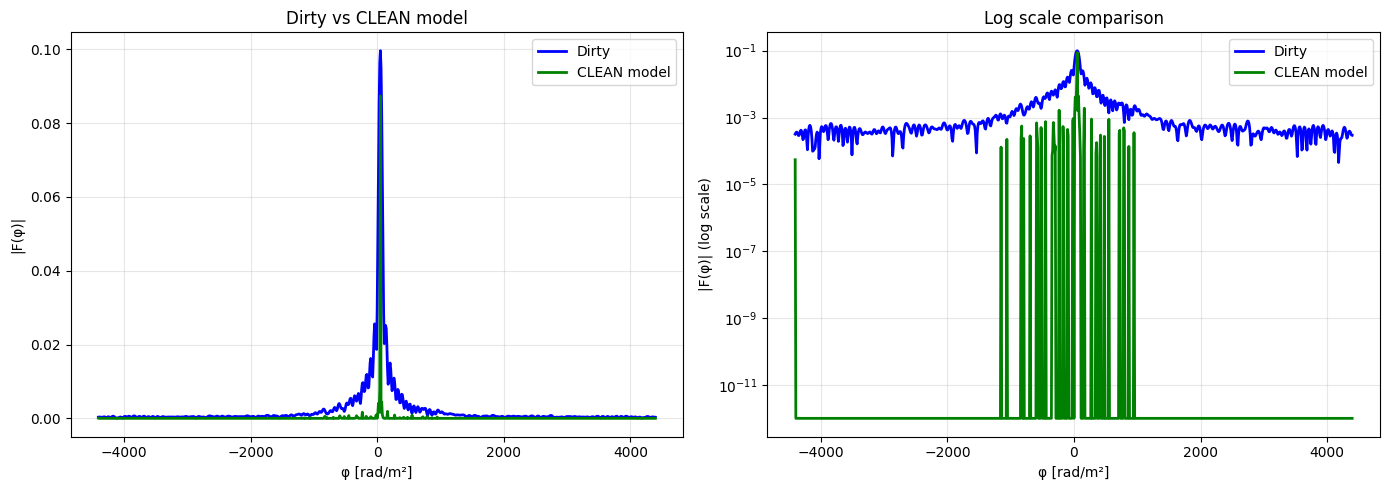

In [5]:
# Analyze sparsity (CLEAN model is inherently sparse)
threshold_frac = 0.1
dirty_nonzero = np.sum(np.abs(fd_dirty) > np.max(np.abs(fd_dirty)) * threshold_frac)
model_nonzero = np.sum(np.abs(fd_model) > np.max(np.abs(fd_model)) * threshold_frac)

print("Sparsity Analysis:")
print(f"  Dirty spectrum: {dirty_nonzero} significant points (>{threshold_frac*100:.0f}% of peak)")
print(f"  CLEAN model: {model_nonzero} significant points (>{threshold_frac*100:.0f}% of peak)")
if model_nonzero > 0:
    print(f"  Sparsity improvement: {dirty_nonzero / model_nonzero:.1f}x")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(phi, np.abs(fd_dirty), 'b-', linewidth=2, label='Dirty')
axes[0].plot(phi, np.abs(fd_model), 'g-', linewidth=2, label='CLEAN model')
axes[0].set_xlabel('φ [rad/m²]')
axes[0].set_ylabel('|F(φ)|')
axes[0].set_title('Dirty vs CLEAN model')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(phi, np.abs(fd_dirty) + 1e-12, 'b-', linewidth=2, label='Dirty')
axes[1].semilogy(phi, np.abs(fd_model) + 1e-12, 'g-', linewidth=2, label='CLEAN model')
axes[1].set_xlabel('φ [rad/m²]')
axes[1].set_ylabel('|F(φ)| (log scale)')
axes[1].set_title('Log scale comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()